<a href="https://colab.research.google.com/github/canerreally-commits/Study-Step2-Spotify/blob/main/Spotify_Step2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Первичный аудит данных

**Датасет:** Spotify Global Chart Totals & Lyrics.

**Задача:** бинарная классификация.

# 1. Загрузка данных и библиотек

In [1]:
!pip install -q opendatasets legacy-cgi

import opendatasets as od

In [2]:
od.download("https://www.kaggle.com/datasets/batudev/spotify-global-chart-totals-and-lyrics")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: canerreally
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/batudev/spotify-global-chart-totals-and-lyrics


100%|██████████| 5.17M/5.17M [00:00<00:00, 131MB/s]

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df_raw = pd.read_csv("/content/spotify-global-chart-totals-and-lyrics/data.csv")
df_raw.head()

,artist and title,wks,t10,pk,x?,PkStreams,total,artist name,song name,lyrics
0,The Weeknd - Blinding Lights,347,64.0,1,(x13),52375259,5441240333,The Weeknd,Blinding Lights,Yeah I've been tryna call I've been on my own ...
1,Ed Sheeran - Shape of You,424,34.0,1,(x14),64217796,4470842634,Ed Sheeran,Shape of You,The club isn't the best place to find a lover ...
2,Harry Styles - As It Was,218,60.0,1,(x11),78460903,4417264164,Harry Styles,As It Was,﻿ As It Was - Harry Styles Come on Harry we wa...
3,The Neighbourhood - Sweater Weather,333,NaN,16,NaN,21624450,4142643719,The Neighbourhood,Sweater Weather,And all I am is a man I want the world in my h...
4,Lewis Capaldi - Someone You Loved,343,15.0,4,NaN,24962682,3933581891,Lewis Capaldi,Someone You Loved,I'm going under and this time I fear there's n...


In [5]:
df = df_raw.copy()

In [6]:
df["Top10"] = (df["pk"] <= 10).astype(int)

## 2. Общая информация

In [7]:
df_raw.shape

(8058, 10)

In [8]:
df_raw.columns

Index(['artist and title', 'wks', 't10', 'pk', 'x?', 'PkStreams', 'total',
       'artist name', 'song name', 'lyrics'],
      dtype='object')

In [9]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8058 entries, 0 to 8057
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   artist and title  8058 non-null   object 
 1   wks               8058 non-null   int64  
 2   t10               810 non-null    float64
 3   pk                8058 non-null   int64  
 4   x?                334 non-null    object 
 5   PkStreams         8058 non-null   int64  
 6   total             8058 non-null   int64  
 7   artist name       8056 non-null   object 
 8   song name         8058 non-null   object 
 9   lyrics            8043 non-null   object 
dtypes: float64(1), int64(4), object(5)
memory usage: 629.7+ KB


In [10]:
df_raw.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
wks,8058.0,1.551000e+01,3.092000e+01,1.0,1.00,4.0,1.700000e+01,4.570000e+02
t10,810.0,8.210000e+00,8.980000e+00,1.0,1.00,5.0,1.300000e+01,7.100000e+01
pk,8058.0,8.366000e+01,6.013000e+01,1.0,30.00,74.0,1.320000e+02,2.460000e+02
PkStreams,8058.0,1.156726e+07,1.025781e+07,166910.0,5368127.50,8941469.5,1.414555e+07,1.288961e+08
total,8058.0,1.419280e+08,3.394366e+08,166910.0,8916825.25,27980926.5,1.188043e+08,5.441240e+09


## 3. Пропущенные значения

In [11]:
df_raw.isna().sum()

,0
artist and title,0
wks,0
t10,7248
pk,0
x?,7724
PkStreams,0
total,0
artist name,2
song name,0
lyrics,15


In [12]:
(df_raw.isna().mean() * 100).round(2)

,0
artist and title,0.00
wks,0.00
t10,89.95
pk,0.00
x?,95.86
PkStreams,0.00
total,0.00
artist name,0.02
song name,0.00
lyrics,0.19


In [13]:
pd.crosstab(df_raw["pk"] <= 10, df_raw["t10"].isna())

t10,False,True
pk,,
False,0,7248
True,810,0


In [14]:
df["t10"] = df["t10"].fillna(0)

In [15]:
df["x?"] = df["x?"].fillna("не указано")

In [16]:
df["artist name"] = df["artist name"].fillna(df["artist and title"].str.split(" -", n=1).str[0])

In [17]:
df["lyrics"] = df["lyrics"].fillna("")

In [18]:
df.isna().sum()

,0
artist and title,0
wks,0
t10,0
pk,0
x?,0
PkStreams,0
total,0
artist name,0
song name,0
lyrics,0


Пропуски в t10 заполнены нулями для песен, не попавших в Top 10. В x? записано «не указано», в lyrics — пустая строка, а имена исполнителей восстановлены из artist and title.

## 4. Дубликаты

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

In [21]:
df.duplicated().sum()

np.int64(0)

## 5. Уникальные значения и константные признаки

In [22]:
df.nunique(dropna=False)

,0
artist and title,7971
wks,200
t10,46
pk,239
x?,17
PkStreams,8057
total,8058
artist name,1794
song name,7277
lyrics,7784


In [23]:
df.columns[df.nunique(dropna=False) == 1].tolist()

[]

## 6. Баланс классов

In [24]:
df["Top10"].value_counts()

,count
Top10,
0,7248
1,810


In [25]:
(df["Top10"].value_counts(normalize=True) * 100).round(2)

,proportion
Top10,
0,89.95
1,10.05


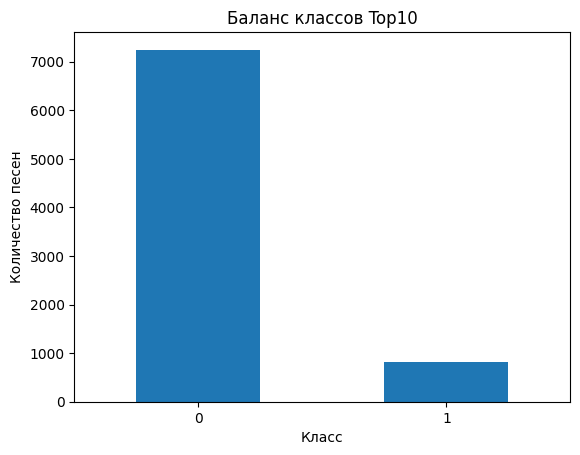

In [26]:
df["Top10"].value_counts().sort_index().plot.bar()
plt.title("Баланс классов Top10")
plt.xlabel("Класс")
plt.ylabel("Количество песен")
plt.xticks(rotation=0)
plt.show()

Классы несбалансированы: около 10% песен достигли Top 10.

## 7. Распределения числовых признаков

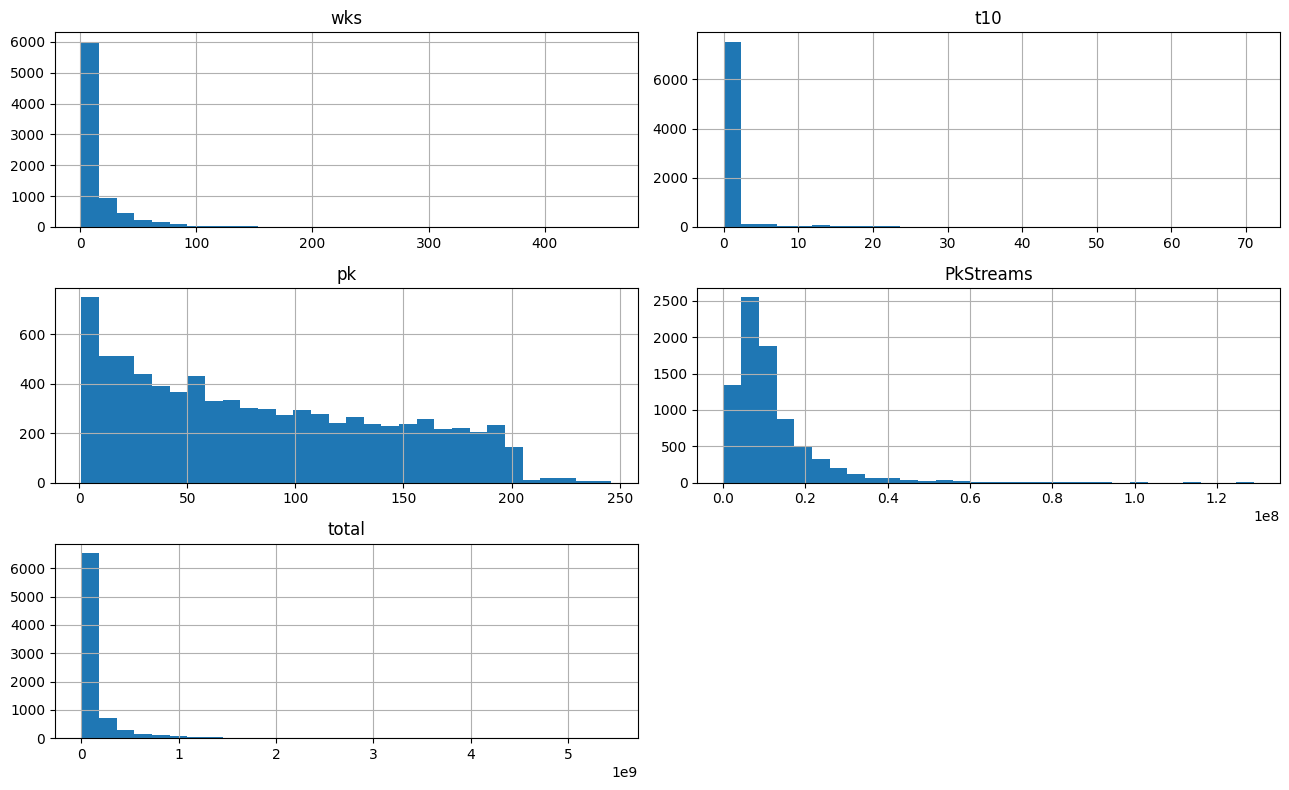

In [27]:
df[["wks", "t10", "pk", "PkStreams", "total"]].hist(bins=30, figsize=(13, 8))
plt.tight_layout()
plt.show()

Распределения wks, PkStreams и total несимметричные: у небольшого числа песен значения значительно выше остальных.

## 8. Boxplot признаков

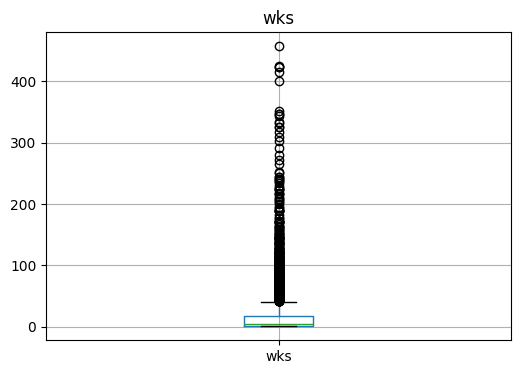

In [28]:
df.boxplot(column="wks", figsize=(6, 4))
plt.title("wks")
plt.show()

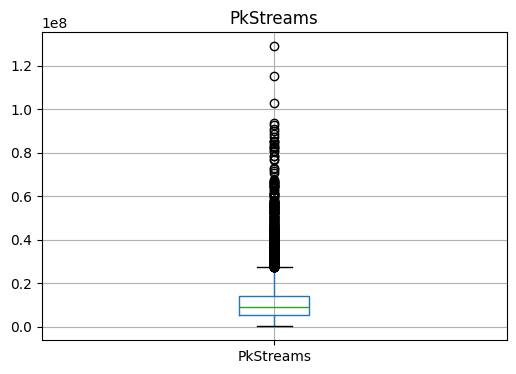

In [29]:
df.boxplot(column="PkStreams", figsize=(6, 4))
plt.title("PkStreams")
plt.show()

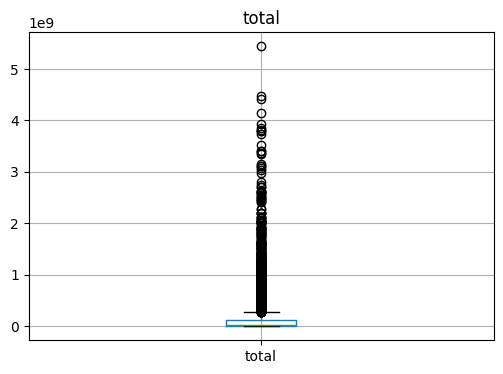

In [30]:
df.boxplot(column="total", figsize=(6, 4))
plt.title("total")
plt.show()

In [31]:
for col in ["wks", "PkStreams", "total"]:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    count = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(col, "— выбросов:", count)

wks — выбросов: 782
PkStreams — выбросов: 522
total — выбросов: 1019


По правилу 1,5 IQR выбросы обнаружены во всех трёх признаках. Высокие значения могут соответствовать действительно популярным песням, поэтому удалять их не требуется.

## 9. Профиль исходной таблицы

In [32]:
profile = pd.DataFrame({
    "Тип": df_raw.dtypes,
    "Заполнено": df_raw.notna().sum(),
    "Пропуски": df_raw.isna().sum(),
    "Пропуски, %": (df_raw.isna().mean() * 100).round(2),
    "Уникальных": df_raw.nunique()
})

In [33]:
profile

,Тип,Заполнено,Пропуски,"Пропуски, %",Уникальных
artist and title,object,8058,0,0.00,7971
wks,int64,8058,0,0.00,200
t10,float64,810,7248,89.95,45
pk,int64,8058,0,0.00,239
x?,object,334,7724,95.86,16
PkStreams,int64,8058,0,0.00,8057
total,int64,8058,0,0.00,8058
artist name,object,8056,2,0.02,1793
song name,object,8058,0,0.00,7277
lyrics,object,8043,15,0.19,7783


## 10. Вывод

В исходном датасете 8058 строк и 10 столбцов. Пропуски обнаружены в t10 (7248), x? (7724), artist name (2) и lyrics (15). В рабочей таблице они заполнены. Полных дубликатов и константных признаков нет.

Из 8058 песен 810 достигли Top 10, а 7248 не достигли, поэтому классы несбалансированы. По графикам распределений и boxplot видны высокие значения и потенциальные выбросы в wks, PkStreams и total. Их нельзя считать ошибками только по величине, поэтому данные оставлены без удаления выбросов.

Для дальнейшего прогнозирования нельзя использовать pk, t10, x?, wks, PkStreams и total как входные признаки: они отражают результат нахождения песни в чарте.